In [12]:
import sys
sys.path.insert(1,'..')
from evo_sim import evo_sim
import numpy as np
import matplotlib.pyplot as plt

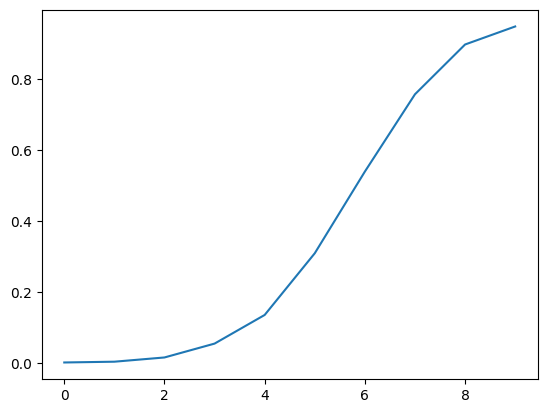

In [2]:
theta = np.array([-2.,-2.,-2.,-5.,-8.,-7.])
y = evo_sim(theta)

plt.plot(y[0:10])

In [ ]:
from inference_utils import get_prior
import torch
prior = get_prior('EVO_SIM')

def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps

theta_test = prior.sample((100,))
x_test = torch.empty(100,10, 30)
for i in range(100):
    x_test[i] = EVO_SIM_wrapper(10, theta_test[i])


torch.save(x_test, 'x_test.pt')
torch.save(theta_test, 'theta_test.pt')

In [20]:
from collective_posterior import CollectivePosterior
import pickle

posterior = pickle.load(open('posterior_EVO_SIM_30000_20.pkl', 'rb'))
j = 10
cp = CollectivePosterior(prior, amortized_posterior=posterior, log_C=1, Xs=x_test[j], epsilon=-10000)
cp.get_log_C()
print(cp.mcmc_from_top_sn(500).mean(0),'\n', theta_test[j])

MCMC from top SN: 100%|██████████| 500/500 [00:05<00:00, 71.67it/s]

tensor([-2.5176, -1.8350, -2.3940, -6.5464, -7.3437, -5.6494]) 
 tensor([-2.9069, -1.7836, -2.3562, -7.2833, -7.8520, -5.4745])
